# VideoMeta test: motion → spatial features → local Qwen events

This runs the package's source pipeline step by step against the bundled MEVA test video:

1. Read video metadata and score motion.
2. Select the highest-motion windows.
3. Track objects and derive their bounding boxes and spatial trajectories.
4. Create annotated window clips and give them with spatial features to local MLX Qwen3-VL.
5. Save the combined annotations to JSON.

In [52]:
# Run once, then restart the kernel if packages were installed or upgraded.
# Use the absolute project path because Jupyter's working directory may not be this notebook's folder.
%pip install --quiet --upgrade -e "/Users/juanvargas/UTS/3rd Semester/Capstone/videometa" opencv-python ultralytics mlx-vlm matplotlib

Note: you may need to restart the kernel to use updated packages.


In [53]:
import json
import logging
from pathlib import Path

import matplotlib.pyplot as plt

from videometa import (
    DetectionConfig,
    LocalQwenEventAnnotator,
    MotionGateConfig,
    ObjectBoundaryExtractor,
    RelevantWindowFinder,
    WindowSpatialFeatureJoiner,
    resolve_video_source,
)

logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(name)s | %(message)s")

# Accepts a local pathlib.Path/string or a public HTTP(S) URL. URLs are cached
# locally by VideoMeta before OpenCV and YOLO read them.
VIDEO_SOURCE = Path("2018-03-05.13-15-00.13-20-00.bus.G340.r13.avi")
# VIDEO_SOURCE = "https://example.com/video.mp4"
OUTPUT_DIR = Path("pipeline_output")
OUTPUT_DIR.mkdir(exist_ok=True)

# Process every motion-relevant window. Set an integer only for a faster test run.
MAX_WINDOWS = None

# Keep the full source frames and spatial JSON, but write a smaller 16:9 MP4
# specifically for local Qwen inference.
QWEN_ANNOTATED_VIDEO_SIZE = (640, 360)
QWEN_ANNOTATED_VIDEO_FPS = 4
# Hard cap on frames per window MP4. At 2 FPS a 5-second window is 10 frames,
# so this only bites if window_seconds is raised later.
QWEN_ANNOTATED_VIDEO_MAX_FRAMES = 32

# Qwen3-VL runs locally through MLX; no API URL or key is required.
# The annotation stage itself lives in test_local_qwen_window_annotation.ipynb.
LOCAL_QWEN_MODEL = "mlx-community/Qwen3-VL-4B-Instruct-4bit"

## 1. Motion significance

`RelevantWindowFinder` decodes the video once, uses background subtraction to score motion, and groups samples into time windows.

2026-08-31 17:13:09,742 | INFO | videometa.annotation | Using local video source: 2018-03-05.13-15-00.13-20-00.bus.G340.r13.avi
2026-08-31 17:13:09,754 | INFO | videometa.annotation | Probed video: 2018-03-05.13-15-00.13-20-00.bus.G340.r13.avi (9005 frames, 30.00 FPS, 1920x1080)
2026-08-31 17:13:09,755 | INFO | videometa.annotation | Sampling motion at 30.0 FPS for 2018-03-05.13-15-00.13-20-00.bus.G340.r13.avi
2026-08-31 17:13:38,372 | INFO | videometa.annotation | Collected 9005 motion samples
2026-08-31 17:13:38,376 | INFO | videometa.annotation | Built 31 motion windows (17 relevant)


VideoInfo(path='2018-03-05.13-15-00.13-20-00.bus.G340.r13.avi', fps=30.0, frame_count=9005, width=1920, height=1080)
Relevant windows: 17 / 31


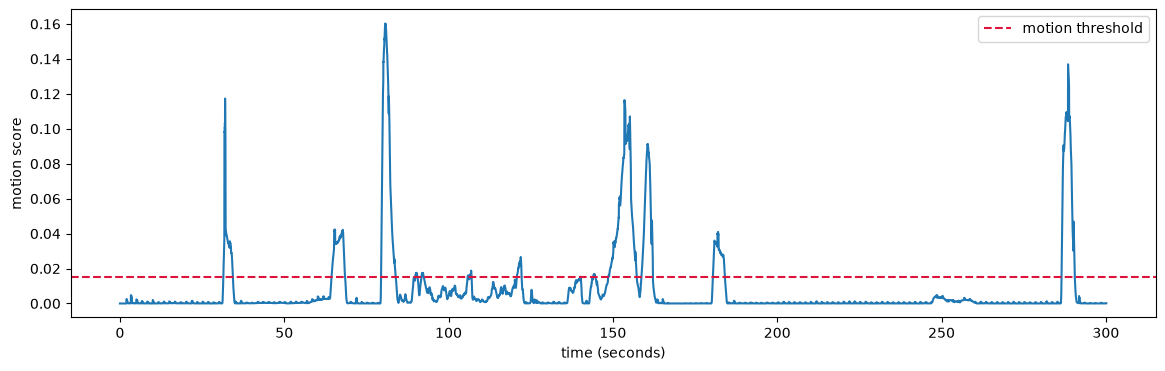

In [54]:
motion_config = MotionGateConfig(
    window_seconds=12,
    stride_seconds=10,
    motion_threshold=0.015,
    warmup_seconds=2,
    mog_history=100,
)
window_finder = RelevantWindowFinder(motion_config)
video_info, motion_samples = window_finder.sample_motion(VIDEO_SOURCE)
windows = window_finder.build_windows(motion_samples, video_info.duration_seconds)
relevant_windows = [window for window in windows if window.is_relevant]

print(video_info)
print(f"Relevant windows: {len(relevant_windows)} / {len(windows)}")

plt.figure(figsize=(14, 4))
plt.plot([sample.timestamp_seconds for sample in motion_samples], [sample.score for sample in motion_samples])
plt.axhline(motion_config.motion_threshold, color="crimson", linestyle="--", label="motion threshold")
plt.xlabel("time (seconds)")
plt.ylabel("motion score")
plt.legend()
plt.show()

## 2. Select motion windows

For this test, use the windows with the greatest peak motion. The library's `RelevantWindow` preserves both frame and timestamp boundaries.

In [55]:
relevant_windows

[RelevantWindow(start_seconds=20.0, end_seconds=32.0, start_frame=600, end_frame=959, sample_count=360, peak_motion=0.103303, mean_motion=0.002745, is_relevant=True),
 RelevantWindow(start_seconds=30.0, end_seconds=42.0, start_frame=900, end_frame=1259, sample_count=360, peak_motion=0.117305, mean_motion=0.010415, is_relevant=True),
 RelevantWindow(start_seconds=60.0, end_seconds=72.0, start_frame=1800, end_frame=2159, sample_count=360, peak_motion=0.0424, mean_motion=0.013205, is_relevant=True),
 RelevantWindow(start_seconds=70.0, end_seconds=82.0, start_frame=2100, end_frame=2459, sample_count=360, peak_motion=0.160243, mean_motion=0.026366, is_relevant=True),
 RelevantWindow(start_seconds=80.0, end_seconds=92.0, start_frame=2400, end_frame=2759, sample_count=360, peak_motion=0.160243, mean_motion=0.034617, is_relevant=True),
 RelevantWindow(start_seconds=90.0, end_seconds=102.0, start_frame=2700, end_frame=3059, sample_count=360, peak_motion=0.017543, mean_motion=0.007594, is_releva

In [56]:
selected_windows = sorted(relevant_windows, key=lambda window: window.peak_motion, reverse=True)
if MAX_WINDOWS is not None:
    selected_windows = selected_windows[:MAX_WINDOWS]

if not selected_windows:
    raise ValueError("No relevant windows selected. Lower motion_threshold and rerun the motion stage.")

for index, window in enumerate(selected_windows, start=1):
    print(
        f"Window {index}: {window.start_seconds:.1f}s–{window.end_seconds:.1f}s "
        f"(frames {window.start_frame}–{window.end_frame}), peak={window.peak_motion:.4f}"
    )

Window 1: 70.0s–82.0s (frames 2100–2459), peak=0.1602
Window 2: 80.0s–92.0s (frames 2400–2759), peak=0.1602
Window 3: 280.0s–292.0s (frames 8400–8759), peak=0.1369
Window 4: 30.0s–42.0s (frames 900–1259), peak=0.1173
Window 5: 150.0s–162.0s (frames 4500–4859), peak=0.1164
Window 6: 20.0s–32.0s (frames 600–959), peak=0.1033
Window 7: 160.0s–172.0s (frames 4800–5159), peak=0.0913
Window 8: 140.0s–152.0s (frames 4200–4559), peak=0.0576
Window 9: 290.0s–300.2s (frames 8700–9004), peak=0.0469
Window 10: 60.0s–72.0s (frames 1800–2159), peak=0.0424
Window 11: 180.0s–192.0s (frames 5400–5759), peak=0.0410
Window 12: 170.0s–182.0s (frames 5100–5459), peak=0.0402
Window 13: 120.0s–132.0s (frames 3600–3959), peak=0.0265
Window 14: 110.0s–122.0s (frames 3300–3659), peak=0.0262
Window 15: 100.0s–112.0s (frames 3000–3359), peak=0.0188
Window 16: 90.0s–102.0s (frames 2700–3059), peak=0.0175
Window 17: 130.0s–142.0s (frames 3900–4259), peak=0.0154


## 3. Spatial features

`ObjectBoundaryExtractor` runs its detector/tracker over only the selected windows. It returns each object's class, confidence, pixel boundary, normalized boundary, and named spatial position.

In [57]:
boundary_extractor = ObjectBoundaryExtractor(
    DetectionConfig(
        model_path="yolo26n.pt",
        confidence_threshold=0.25,
        spatial_grid=3,
    )
)
object_annotations = boundary_extractor.extract(VIDEO_SOURCE, selected_windows, video_info.fps)

spatial_features = []
for annotation in object_annotations:
    objects = [
        {
            "track_id": item.track_id,
            "label": item.label,
            "average_confidence": item.average_confidence,
            "spatial_trajectory": list(item.spatial_trajectory),
            "first_frame": item.first_frame,
            "last_frame": item.last_frame,
        }
        for item in annotation.objects
    ]
    spatial_features.append({
        "window": {
            "start_seconds": annotation.window.start_seconds,
            "end_seconds": annotation.window.end_seconds,
            "start_frame": annotation.window.start_frame,
            "end_frame": annotation.window.end_frame,
        },
        "objects": objects,
    })

(OUTPUT_DIR / "spatial_features.json").write_text(json.dumps(spatial_features, indent=2), encoding="utf-8")
print(json.dumps(spatial_features, indent=2))

2026-08-31 17:13:38,429 | INFO | videometa.annotation | Using local video source: 2018-03-05.13-15-00.13-20-00.bus.G340.r13.avi
2026-08-31 17:13:38,439 | INFO | videometa.annotation | Tracking full video for spatial features in 17 relevant windows: 2018-03-05.13-15-00.13-20-00.bus.G340.r13.avi
2026-08-31 17:16:01,256 | INFO | videometa.annotation | Assigned 8 global tracks to 360 frames in window 70.000s–82.000s
2026-08-31 17:16:01,257 | INFO | videometa.annotation | Assigned 15 global tracks to 360 frames in window 80.000s–92.000s
2026-08-31 17:16:01,257 | INFO | videometa.annotation | Assigned 10 global tracks to 360 frames in window 280.000s–292.000s
2026-08-31 17:16:01,258 | INFO | videometa.annotation | Assigned 14 global tracks to 360 frames in window 30.000s–42.000s
2026-08-31 17:16:01,258 | INFO | videometa.annotation | Assigned 10 global tracks to 360 frames in window 150.000s–162.000s
2026-08-31 17:16:01,258 | INFO | videometa.annotation | Assigned 10 global tracks to 360 fra

[
  {
    "window": {
      "start_seconds": 70.0,
      "end_seconds": 82.0,
      "start_frame": 2100,
      "end_frame": 2459
    },
    "objects": [
      {
        "track_id": 2,
        "label": "car",
        "average_confidence": 0.5507,
        "spatial_trajectory": [
          "top-center"
        ],
        "first_frame": 2100,
        "last_frame": 2459
      },
      {
        "track_id": 4,
        "label": "car",
        "average_confidence": 0.4072,
        "spatial_trajectory": [
          "top-center"
        ],
        "first_frame": 2100,
        "last_frame": 2459
      },
      {
        "track_id": 668,
        "label": "car",
        "average_confidence": 0.341,
        "spatial_trajectory": [
          "top-left"
        ],
        "first_frame": 2100,
        "last_frame": 2459
      },
      {
        "track_id": 1,
        "label": "truck",
        "average_confidence": 0.5898,
        "spatial_trajectory": [
          "top-center"
        ],
        "first_

In [58]:
spatial_features

[{'window': {'start_seconds': 70.0,
   'end_seconds': 82.0,
   'start_frame': 2100,
   'end_frame': 2459},
  'objects': [{'track_id': 2,
    'label': 'car',
    'average_confidence': 0.5507,
    'spatial_trajectory': ['top-center'],
    'first_frame': 2100,
    'last_frame': 2459},
   {'track_id': 4,
    'label': 'car',
    'average_confidence': 0.4072,
    'spatial_trajectory': ['top-center'],
    'first_frame': 2100,
    'last_frame': 2459},
   {'track_id': 668,
    'label': 'car',
    'average_confidence': 0.341,
    'spatial_trajectory': ['top-left'],
    'first_frame': 2100,
    'last_frame': 2459},
   {'track_id': 1,
    'label': 'truck',
    'average_confidence': 0.5898,
    'spatial_trajectory': ['top-center'],
    'first_frame': 2100,
    'last_frame': 2459},
   {'track_id': 721,
    'label': 'car',
    'average_confidence': 0.3406,
    'spatial_trajectory': ['top-left'],
    'first_frame': 2100,
    'last_frame': 2459},
   {'track_id': 842,
    'label': 'car',
    'average_co

## 4. Local Qwen3-VL input: window frames + spatial features

The source frames and their full-resolution spatial JSON are preserved on disk. Separately,
a small 640x360 / 2 FPS MP4 is written per window for local inference — about 10 frames,
which is roughly 1,100 visual tokens through Qwen3-VL.

Two settings here exist purely to keep the downstream MLX run inside the Metal memory
budget on a 24 GB Mac:

- `encode_frame_images=False` skips base64-encoding every frame into `image_messages`.
  Only the remote OpenAI-style path needs those; holding ~20 MB per window across 41
  windows costs close to a gigabyte of host RAM for nothing.
- The per-frame spatial JSON is still written in full to `prepared_windows.json`, but the
  annotator now samples and compacts it before building a prompt. Sending all 150 frames
  of a window verbatim produced ~66,000 tokens, and the KV cache for that alone is about
  10 GB — which is what caused the earlier `kIOGPUCommandBufferCallbackErrorOutOfMemory`
  crash during prefill.

In [59]:
# Stage 4a is implemented in videometa.src. It joins sampled video frames with
# their tracked spatial boundaries and labels, then optionally persists them.
FRAME_OUTPUT_DIR = OUTPUT_DIR / "window_frames"

In [60]:
# Stage 4a: join and optionally save annotated frames + spatial features.
source_path = resolve_video_source(VIDEO_SOURCE)

joiner = WindowSpatialFeatureJoiner(
    output_directory=FRAME_OUTPUT_DIR,   # set to None to skip frame artifacts
    annotated_video_size=QWEN_ANNOTATED_VIDEO_SIZE,
    annotated_video_fps=QWEN_ANNOTATED_VIDEO_FPS,
    annotated_video_max_frames=QWEN_ANNOTATED_VIDEO_MAX_FRAMES,
    # The local MLX path reads the annotated MP4, so the base64 JPEG copies are
    # dead weight. Set True only when using LVLMEventAnnotator against a remote API.
    encode_frame_images=False,
)

prepared_windows = [
    joiner.prepare(source_path, annotation) for annotation in object_annotations
]

prepared_manifest = [
    {
        "start_seconds": prepared.start_seconds,
        "end_seconds": prepared.end_seconds,
        "object_features": prepared.object_features,
        "frame_features": prepared.frame_features,
        "artifact_directory": prepared.artifact_directory,
        "annotated_video_path": prepared.annotated_video_path,
    }
    for prepared in prepared_windows
]
(OUTPUT_DIR / "prepared_windows.json").write_text(
    json.dumps(prepared_manifest, indent=2), encoding="utf-8"
)
print(f"Prepared {len(prepared_windows)} windows")

2026-08-31 17:16:01,290 | INFO | videometa.annotation | Using local video source: 2018-03-05.13-15-00.13-20-00.bus.G340.r13.avi
2026-08-31 17:16:01,290 | INFO | videometa.window_annotation | Preparing window 70.000s-82.000s with 360 frames
2026-08-31 17:16:03,136 | INFO | videometa.window_annotation | Writing annotated window video at 640x360, 4.00 FPS, 32 frames: pipeline_output/window_frames/window_70.000s_82.000s/annotated_window.mp4
2026-08-31 17:16:03,138 | INFO | videometa.window_annotation | Using avc1 codec for pipeline_output/window_frames/window_70.000s_82.000s/annotated_window.mp4
2026-08-31 17:16:03,303 | INFO | videometa.window_annotation | Wrote annotated window video (32 frames): pipeline_output/window_frames/window_70.000s_82.000s/annotated_window.mp4
2026-08-31 17:16:03,304 | INFO | videometa.window_annotation | Prepared window 70.000s-82.000s (360 frames, artifacts: pipeline_output/window_frames/window_70.000s_82.000s)
2026-08-31 17:16:03,304 | INFO | videometa.window

Prepared 17 windows


In [61]:
# Verify the artifacts are actually small before switching notebooks.
# If frame_features here is hundreds of thousands of characters, the annotator
# will still sample it down, but this is the number that caused the original OOM.
import subprocess

sample = prepared_windows[0]
print("Window:", f"{sample.start_seconds:.1f}s-{sample.end_seconds:.1f}s")
print("Video :", sample.annotated_video_path)

try:
    probe = subprocess.run(
        ["ffprobe", "-v", "error", "-select_streams", "v:0",
         "-show_entries", "stream=width,height,nb_frames,avg_frame_rate",
         "-of", "default=noprint_wrappers=1", sample.annotated_video_path],
        capture_output=True, text=True, check=True,
    )
    print(probe.stdout.strip())
except (FileNotFoundError, subprocess.CalledProcessError) as error:
    print(f"ffprobe unavailable ({error}); skipping probe")

raw = len(json.dumps(sample.frame_features))
print(f"frame_features: {len(sample.frame_features)} frames, {raw:,} chars (~{raw // 3:,} tokens if sent whole)")
print(f"image_messages: {len(sample.image_messages)} (expected 0 with encode_frame_images=False)")

Window: 70.0s-82.0s
Video : pipeline_output/window_frames/window_70.000s_82.000s/annotated_window.mp4
width=640
height=360
avg_frame_rate=4/1
nb_frames=32
frame_features: 360 frames, 244,632 chars (~81,544 tokens if sent whole)
image_messages: 0 (expected 0 with encode_frame_images=False)


In [62]:
# The local-Qwen annotation stage has moved to:
#   test_local_qwen_window_annotation.ipynb
#
# Restart the kernel before opening it so the YOLO/MPS memory used above is released.
print(f"Prepared {len(prepared_windows)} windows for local Qwen annotation.")
print(f"Open: {(Path.cwd() / 'test_local_qwen_window_annotation.ipynb').resolve()}")

Prepared 17 windows for local Qwen annotation.
Open: /Users/juanvargas/UTS/3rd Semester/Capstone/videometa/tests/test_local_qwen_window_annotation.ipynb
